# <h2> Diabetes Outcome Predictor [Classification Task] </h2>
Name: Rohan Mulla <br>
University: Rabindra Maitree University <br>
E-mail: mdrohanislam444@gmail.com

#Initial Steps
- import necessary header files

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# importing scikit learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import confusion_matrix, classification_report

# import model scikit learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


print("-> All File Has Imported Successfully")

-> All File Has Imported Successfully


#Step 1:
- Load Dataset <a href="https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database" target="_blank">Link</a>  
- Display Few Rows with head
- Print Shapes of desire dataset

In [ ]:
# Load From Raw.Github
url = "https://raw.githubusercontent.com/MullaRohan/dataset_for_machine_learning/refs/heads/main/diabetes_nineCols_SurabhSing.csv"
df = pd.read_csv(url)
print(df.head())
print(f"Fram's Shape -> {df.shape}")
print(f"Info about dataframe \n{df.info()}")

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Fram's Shape -> (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Gluc

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

<b> Observation </b>: There are 9 columns, and 768 rows each column, and there is no non-null cell.

# Step 2:
- Data Preprocessing  
- Handling Missing Value
- Encoding The Categorical Value
- Scaling
- Detect Outlier

<b> Objective: </b> Let's show a plot for understand about the distribution of the dataset. It is necessary to take farther decision.

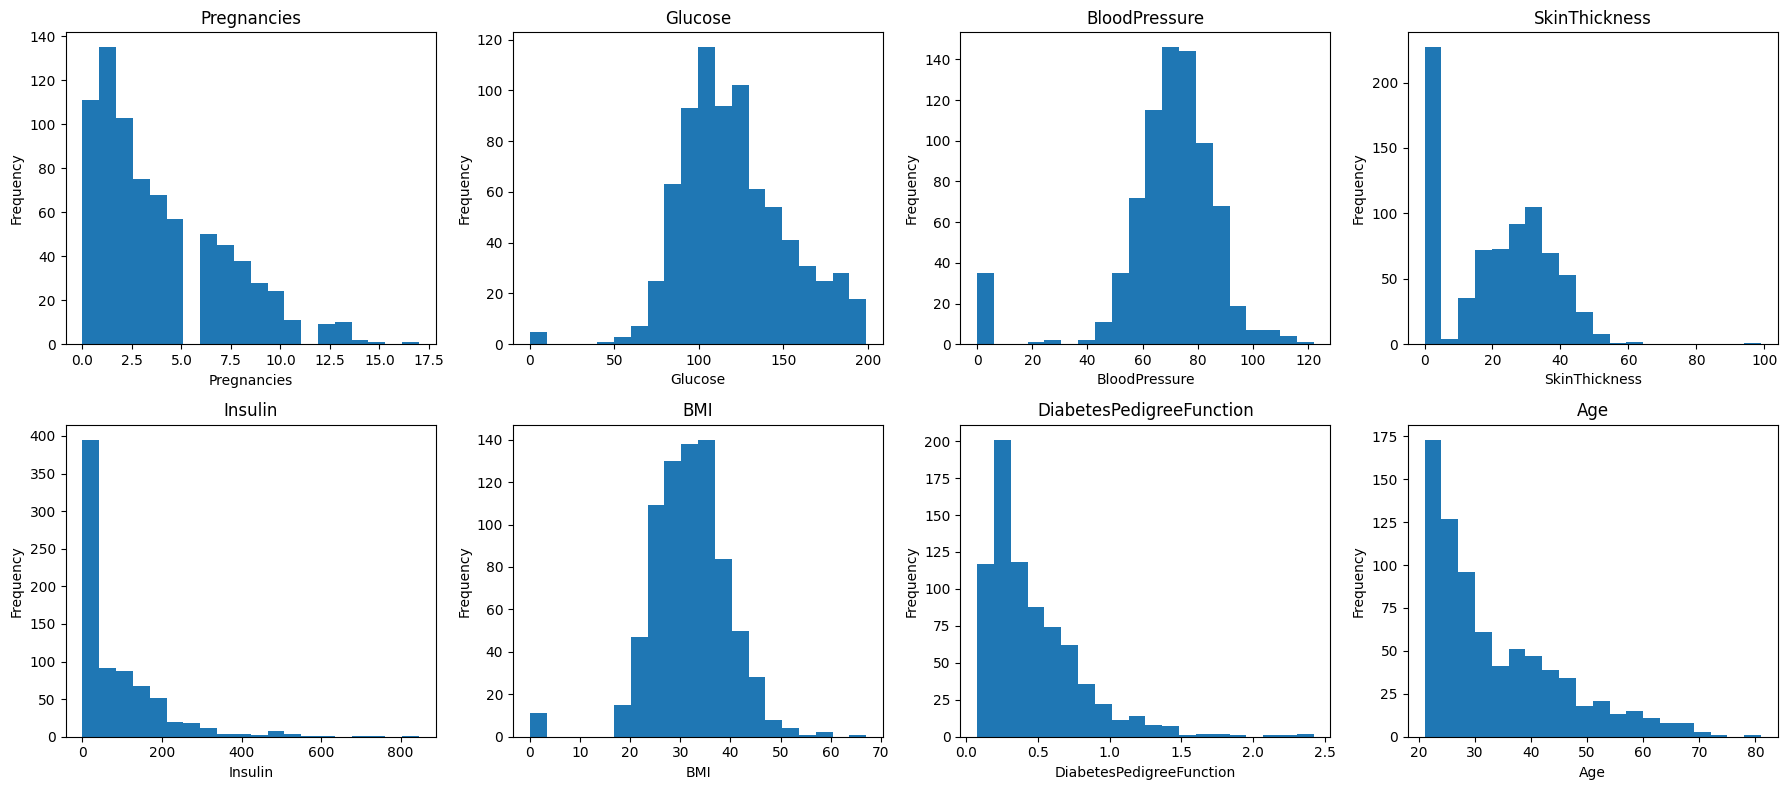

In [ ]:
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

<b> Observation :</b> There are few column that has 0 as value,  
- Gluecose has values as 0, but Gluecose can't be 0
- SkinThickness can't be 0
- BloodPressure can't be 0
- BMI can't be 0
- Insulin can't be 0  
So, These columns has the value of 0, it is impossible for a living person.   
So, we will impute these value with SimpleImputer and strategy will be median.

<b> Objective :</b> Refill 0 as NaN, then impute all with median in columntransformer.

In [ ]:
# Refill 0 as NaNValue
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df.isna().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


<b> Objective : </b> Detect outlier with box plot

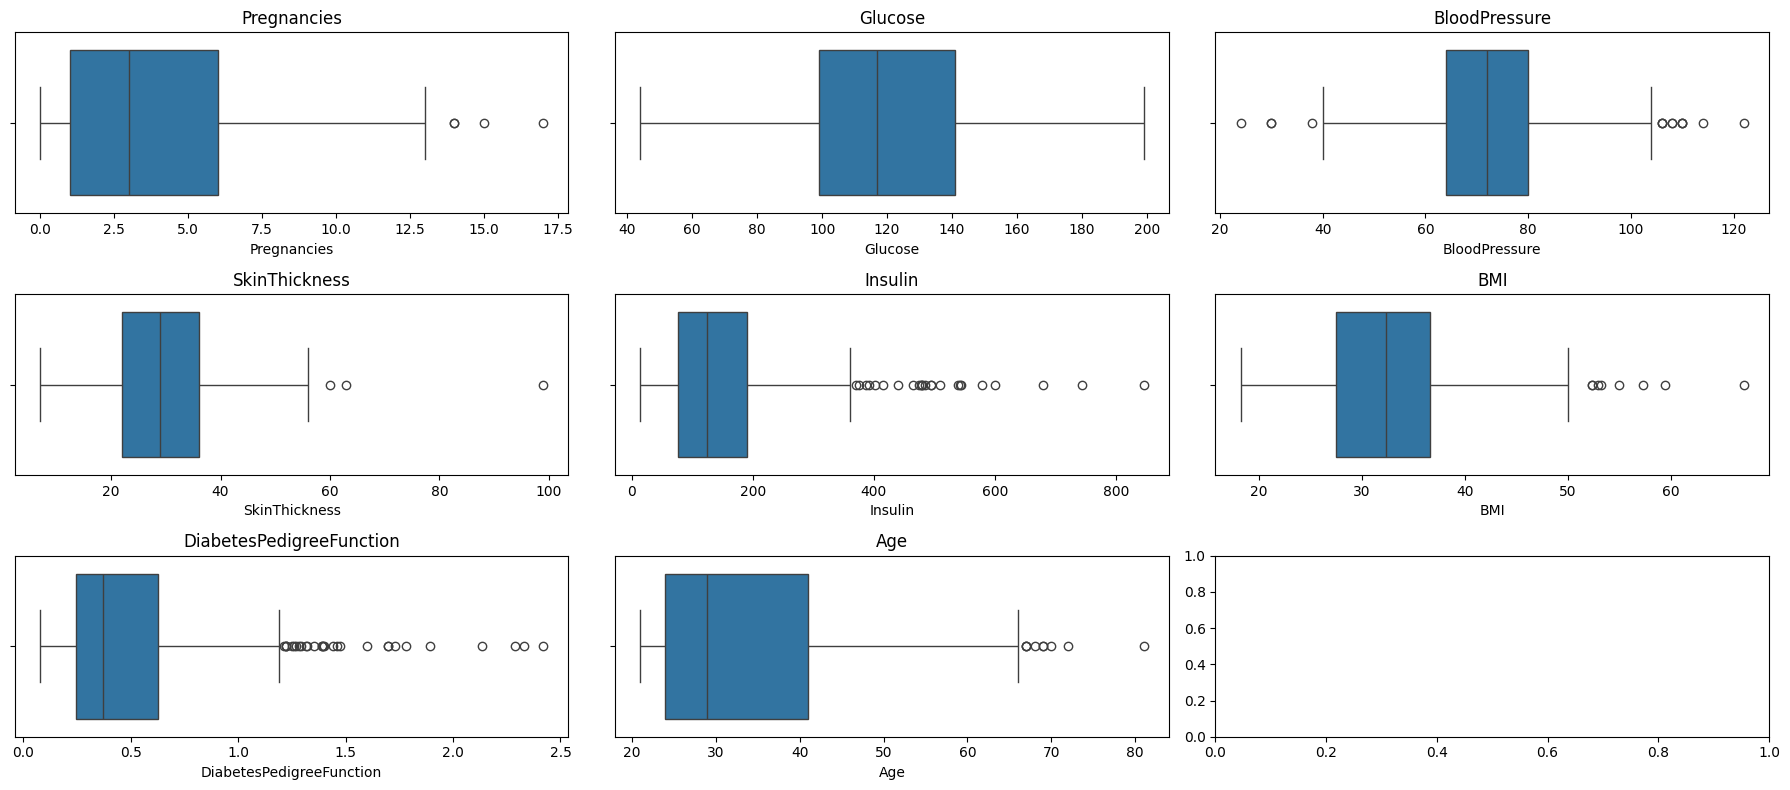

In [ ]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

<b> Observation: </b>
In insulin, bmi, skinthickness and DiabetesPedigreeFunfunction has some outlier.  
for insulin, we will clip (capped) outlier <1% and >99%  
for DiabetesPedigreeFunction, we will use log1p for compress for standard deviation.

In [ ]:
# Insulin
low, high = df["Insulin"].quantile([0.01, 0.99])
df["Insulin"] = df["Insulin"].clip(lower=low, upper=high)
print("-> Insulin Outlier Capped")

# BMI
low, high = df["BMI"].quantile([0.01, 0.99])
df["BMI"] = df["BMI"].clip(lower=low, upper=high)
print("-> BMI Outlier Capped")

# SkinThickness
low, high = df["SkinThickness"].quantile([0.01, 0.99])
df["SkinThickness"] = df["SkinThickness"].clip(lower=low, upper=high)
print("-> SkinThickness Outlier Capped")

# Pregnancies
df["Pregnancies"] = np.log1p(df["Pregnancies"])
print("-> Pregnancies Scaled")

-> Insulin Outlier Capped
-> BMI Outlier Capped
-> SkinThickness Outlier Capped
-> Pregnancies Scaled


<b> TODO: </b>
- define categorical and numerical cols.
- define X, y
- split into train and test

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
num_cols = X.select_dtypes(include = ["int64", "float64"]).columns
cat_cols = X.select_dtypes(include = ["object"]).columns

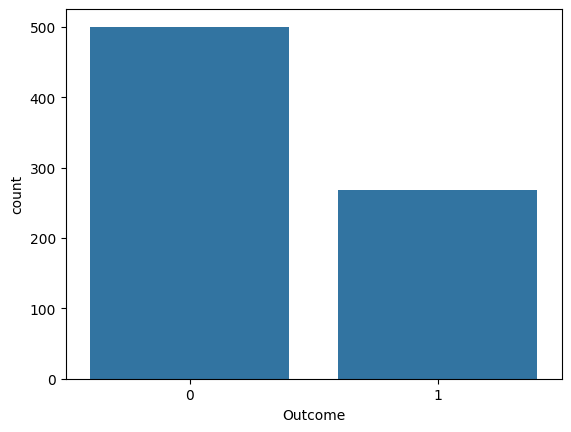

In [ ]:
sns.countplot(df, x="Outcome")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("-> Data Splitted")

-> Data Splitted


# Step 3:
- PipeLine Creation  
- Creating Transformer according to up

In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


In [ ]:
# Preproccess
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

print("Preprocessor Defined")

Preprocessor Defined


<b> why median </b>  
we saw previous almost all column has outlier and right skewed, so i use median,  
we know median is not sensitive for oulier

# Step 4: Primary Model Selection  
- Choosing a primary model
- I'll declare few Model who can deliver classification task.
> LogisticRegressor, SVC[rbf], KNeighbourClassifier

In [ ]:
# TODO: Making a List for model
model_to_train = {
    "L_RG" : LogisticRegression(class_weight="balanced", max_iter=100),
    "SVC" : SVC(kernel="rbf", C=1, gamma="scale"),
    "KNN" : KNeighborsClassifier()
}

# step 5:
- Model Train and evaluating

In [ ]:
result = []
for name, model in model_to_train.items():
  # Pipeline Create
  pipe = Pipeline(
      steps=[
          ("preprocess", preprocessor),
          ("model", model)
      ]
  )
  # fit the model
  pipe.fit(X_train, y_train)
  # predict from model
  y_pred = pipe.predict(X_test)

  #Evaluation
  ev = classification_report(y_test, y_pred, output_dict=True)
  result.append({
    "model" : name,
    "accuracy": ev["accuracy"],
    "precision": ev["1"]["precision"],
    "recall": ev["1"]["recall"],
    "f1_score": ev["1"]["f1-score"]
  })

result_df = pd.DataFrame(result).sort_values(by="f1_score", ascending=False)
result_df

,model,accuracy,precision,recall,f1_score
2,KNN,0.740260,0.622951,0.690909,0.655172
0,L_RG,0.714286,0.582090,0.709091,0.639344
1,SVC,0.746753,0.660000,0.600000,0.628571


<b> Observation: </b>
We'll use Logistic Regression for this dataset. because of high recall.

# Step 6:
- Cross Validation with 5 fold cv

In [ ]:
log_reg = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]
)

In [ ]:
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="recall")
print(f"Recall CV Score -> {cv_scores}")
print(f"Mean Recall CV score -> {cv_scores.mean():.3f}")
print(f"Standard Deviation -> {cv_scores.std():.3f}")

Recall CV Score -> [0.66666667 0.76744186 0.79069767 0.6744186  0.71428571]
Mean Recall CV score -> 0.723
Standard Deviation -> 0.049


# Step 7:
- hyper parameter tuning

In [ ]:
# define grid
param_grid = {
    "model__C": [0.01, 0.1, 1, 2, 5, 10],
    "model__class_weight": ["balanced", None],
    "model__solver": ["liblinear", "saga"]
}


In [ ]:
l_reg = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
grid_search = GridSearchCV(
    estimator = l_reg,
    param_grid = param_grid,
    cv = 5,
    scoring = "recall",
    n_jobs = -1,
    verbose = 2
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index([], dtype='object'))])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 2, 5, 10],
                         'model__class_weight': ['balanced', None],
                         'model__solver': ['liblinear', 'saga']},
             scoring='recall', verbose=2)

In [ ]:
print(grid_search.best_score_)
print(grid_search.best_params_)

0.7557032115171649
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}


# Steps 8:
best model Selection.  
for LogisticRegression  
- C = 0.01
- class_weight = balanced
- solver = liblinear

#Steps 9:
Model Performance and evaluation.

In [ ]:
final_model = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.01, solver="liblinear"))
    ]
)

In [ ]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, solver='liblinear'))])

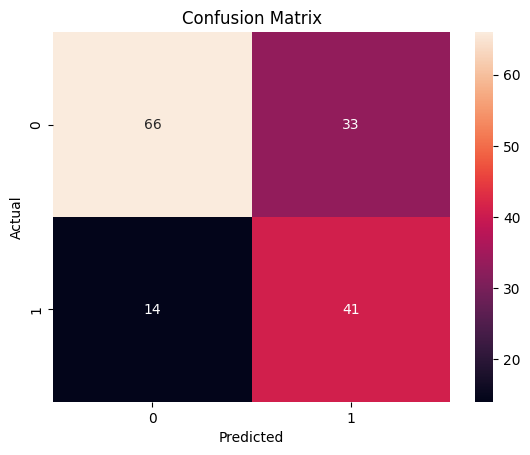

In [ ]:
y_final_pred = final_model.predict(X_test)

#Model Evaluation
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# classification report
print(classification_report(y_test, y_final_pred))

              precision    recall  f1-score   support

           0       0.82      0.67      0.74        99
           1       0.55      0.75      0.64        55

    accuracy                           0.69       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.69      0.70       154



#All Steps are done

In [ ]:
import pickle
file_name = "diabetes_classification.pkl"
with open(file_name, "wb") as file:
  pickle.dump(final_model, file)

In [ ]:
with open("/content/diabetes_classification.pkl", "rb") as file:
  model = pickle.load(file)

In [ ]:

model.predict(X_test)

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0])